# Neural Network Model Training & Tuning

This notebook trains a Neural Network classifier on the linearized session windows data using all available numerical features.
We use `RandomizedSearchCV` with a single static validation split (`PredefinedSplit`) to tune key hyperparameters of the model.

Since the final model will be evaluated against real data from the database, we use the holdout validation set solely for hyperparameter tuning. The model is also evaluated on the real database export dataset.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Add project root directory to path for imports
sys.path.append(str(Path.cwd().parent.parent))

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit, train_test_split
from scripts.data_loader import load_and_preprocess_data
from scripts.evaluation_metrics import evaluate_model

## Load and Preprocess Data

We load the data and extract scaled features, targets, and the fitted scaler using our shared preprocessing script.

In [2]:
X_train, X_test, y_train, y_test, scaler = load_and_preprocess_data()
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (9081, 42)
Test set shape: (2271, 42)


## Hyperparameter Tuning via Randomized Search

We use a static validation split (holdout set) rather than K-Fold cross-validation to save compute time and align with deep learning standards. To combat overfitting, we search across higher L2 regularization coefficient values (alpha) and keep early stopping enabled.

In [3]:
param_dist = {
    'hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64), (64, 32, 16)],
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0, 5.0],
    'learning_rate_init': [0.001, 0.01],
    'solver': ['adam', 'sgd'],
    'learning_rate': ['constant', 'adaptive']
}

# Split training data to create a single static validation set (holdout)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Create a PredefinedSplit where training is -1 and validation is 0
split_index = [-1] * len(X_tr) + [0] * len(X_val)
pds = PredefinedSplit(test_fold=split_index)

# Combine train and validation sets back together for fit()
X_tune = pd.concat([X_tr, X_val])
y_tune = pd.concat([y_tr, y_val])

base_model = MLPClassifier(max_iter=200, random_state=42, early_stopping=True, validation_fraction=0.1)

random_search = RandomizedSearchCV(
    base_model,
    param_distributions=param_dist,
    n_iter=15,
    cv=pds,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_tune, y_tune)

print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Validation Accuracy: {random_search.best_score_:.4f}")

Best Parameters: {'solver': 'adam', 'learning_rate_init': 0.001, 'learning_rate': 'constant', 'hidden_layer_sizes': (128, 64), 'alpha': 0.0001}
Best Validation Accuracy: 0.6824


## Evaluate Best Model

We evaluate the optimized model on the test split of the training dataset.


--- Train Metrics ---
Accuracy:  0.6987
Precision (weighted): 0.6950
Recall (weighted):    0.6987
F1 Score (weighted):  0.6807

--- Test/Validation Metrics ---
Accuracy:  0.6825
Precision (weighted): 0.6714
Recall (weighted):    0.6825
F1 Score (weighted):  0.6631

--- MLP Feature Relevance (Mean Absolute Weights of First Layer, Top 20) ---
cluster              0.116138
noise_mean           0.113490
light_min            0.110309
light_count          0.109989
noise_min            0.109236
noise_count          0.108693
light_mean           0.108501
humidity_std         0.106846
temperature_count    0.106559
humidity_min         0.105468
temperature_mean     0.105267
n_readings           0.105162
light_range          0.104638
noise_std            0.104231
humidity_count       0.104149
co2_latest           0.103806
light_max            0.102841
noise_max            0.102732
co2_count            0.102718
co2_min              0.102447
dtype: float64


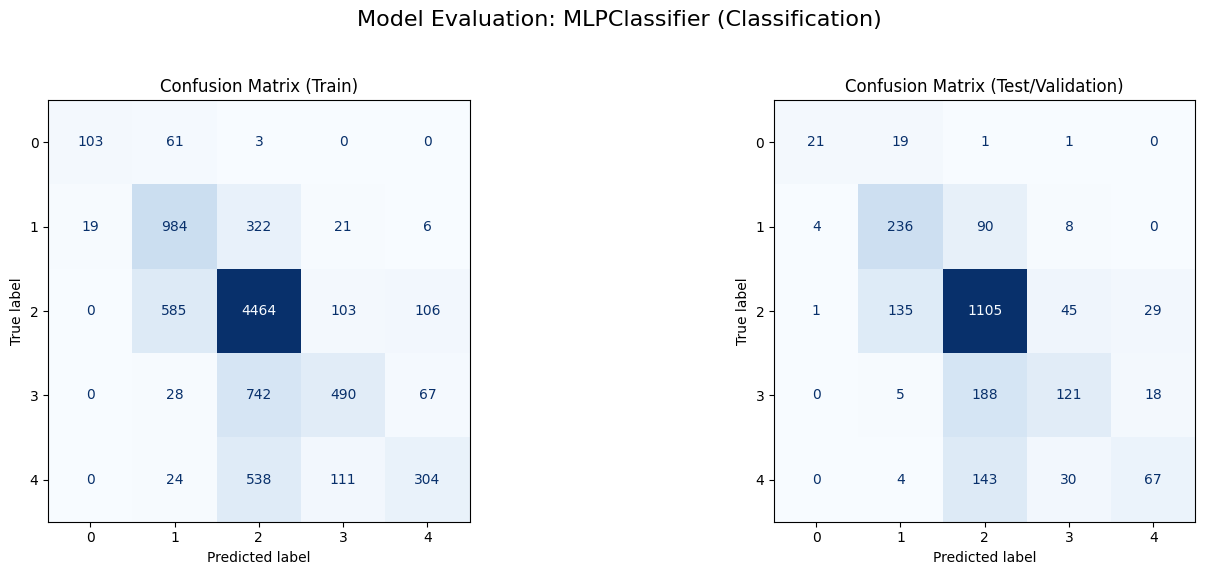

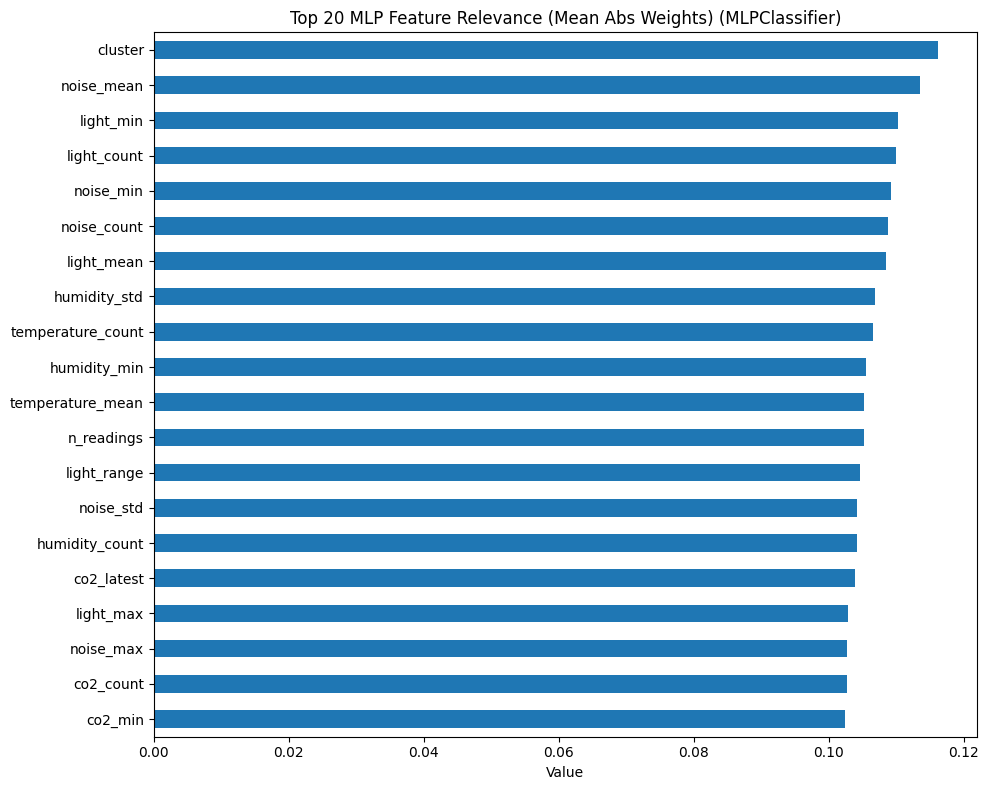

In [4]:
best_model = random_search.best_estimator_
figures = evaluate_model(best_model, X_train, X_test, y_train, y_test, is_classification=True)

## Evaluate on Real Production Data

We load the real session data exported from the database, scale it using the same scaler fitted on our training data, and evaluate our tuned model on it.

In [5]:
# Path to real data generated from the production database
real_data_path = Path("../../data/real/linearized_sessions_with_target.csv")

if real_data_path.exists() and real_data_path.stat().st_size > 0:
    try:
        real_df = pd.read_csv(real_data_path).dropna(subset=["rating"])
        if not real_df.empty:
            # Select features (must match the same feature columns used in training)
            X_real = real_df[X_train.columns]
            y_real = real_df["rating"]
            
            # CRITICAL: Scale real features using the SAME scaler fitted on training data
            X_real_scaled = pd.DataFrame(
                scaler.transform(X_real),
                columns=X_real.columns,
                index=X_real.index
            )
            
            print(f"Loaded {len(real_df)} real sessions for evaluation.")
            # Evaluate using the same evaluation script
            figs_real = evaluate_model(best_model, X_train, X_real_scaled, y_train, y_real, is_classification=True)
        else:
            print("Real data CSV is empty.")
    except Exception as e:
        print(f"Could not load or evaluate real data: {e}")
else:
    print(f"No real data available for testing at: {real_data_path}")

Could not load or evaluate real data: No columns to parse from file
